In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as s
import matplotlib.pyplot as plt
from matplotlib import cm
from itertools import permutations

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


In [2]:
data = pd.read_csv("./data/BreastCancerData.csv")
data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [3]:
data.columns, len(data.columns)

(Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
        'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
        'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
        'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
        'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
        'fractal_dimension_se', 'radius_worst', 'texture_worst',
        'perimeter_worst', 'area_worst', 'smoothness_worst',
        'compactness_worst', 'concavity_worst', 'concave points_worst',
        'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
       dtype='object'),
 33)

In [4]:
data.drop(labels=data.columns[32],axis=1,inplace=True)
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
data.isnull().sum().sort_values(ascending=False)

id                         0
diagnosis                  0
symmetry_worst             0
concave points_worst       0
concavity_worst            0
compactness_worst          0
smoothness_worst           0
area_worst                 0
perimeter_worst            0
texture_worst              0
radius_worst               0
fractal_dimension_se       0
symmetry_se                0
concave points_se          0
concavity_se               0
compactness_se             0
smoothness_se              0
area_se                    0
perimeter_se               0
texture_se                 0
radius_se                  0
fractal_dimension_mean     0
symmetry_mean              0
concave points_mean        0
concavity_mean             0
compactness_mean           0
smoothness_mean            0
area_mean                  0
perimeter_mean             0
texture_mean               0
radius_mean                0
fractal_dimension_worst    0
dtype: int64

In [6]:
data_columns = list(data.columns)
data_columns.remove('id')
data_columns.remove('diagnosis')
data_columns

['radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst']

In [7]:
sample_good_data = {'X':np.concatenate((np.random.normal(loc=50,scale=3,size=(284,)),
                               np.random.normal(loc=80,scale=5,size=(285,))),axis=0),
     'diagnosis':np.concatenate((np.array(['B']*284),np.array(['M']*285)),axis=0)}
sample_good_data = pd.DataFrame(data=sample_good_data)


<Axes: xlabel='X'>

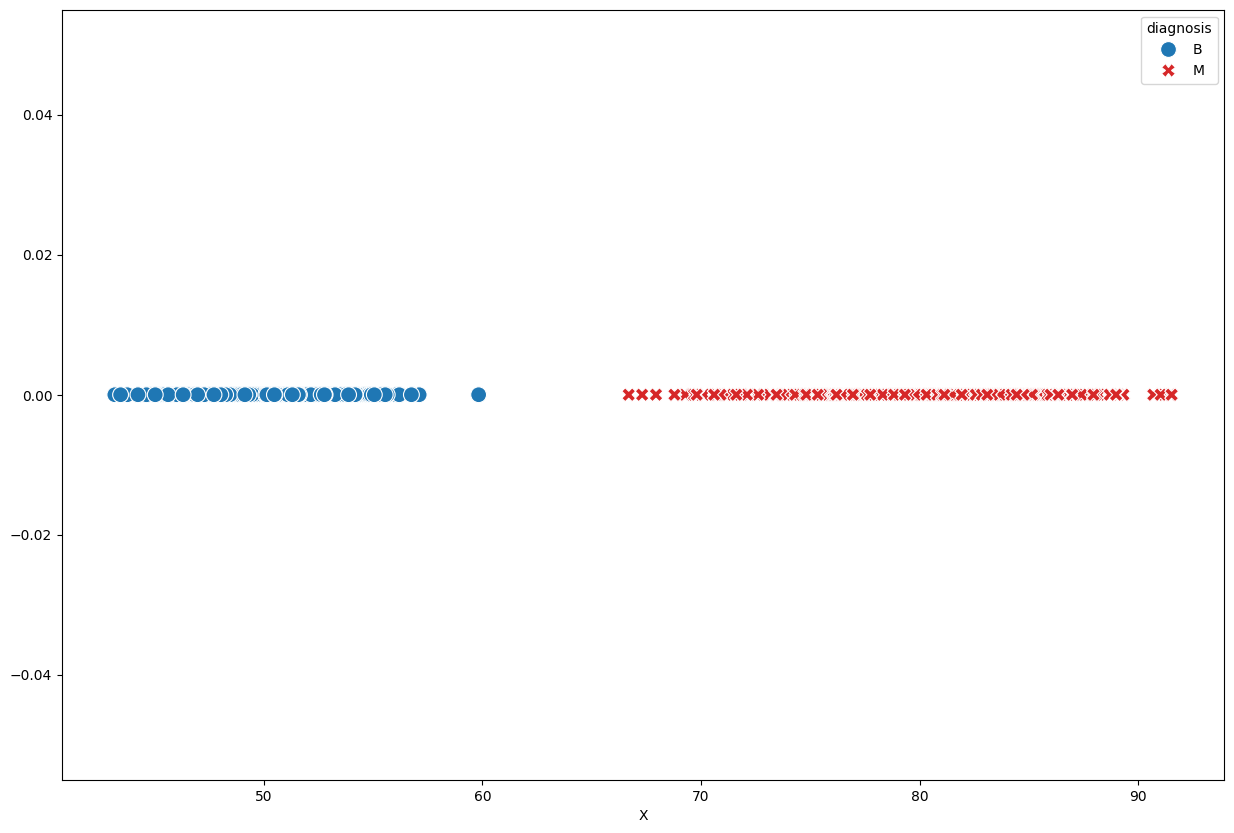

In [8]:
plt.figure(figsize=(15,10))
sns.scatterplot(data=sample_good_data,x=sample_good_data.columns[0],y=[0]*len(sample_good_data),hue='diagnosis',
             palette=[sns.color_palette()[0],sns.color_palette()[3]],style='diagnosis',size='diagnosis',
               sizes=(100,130))


<Axes: xlabel='X', ylabel='Density'>

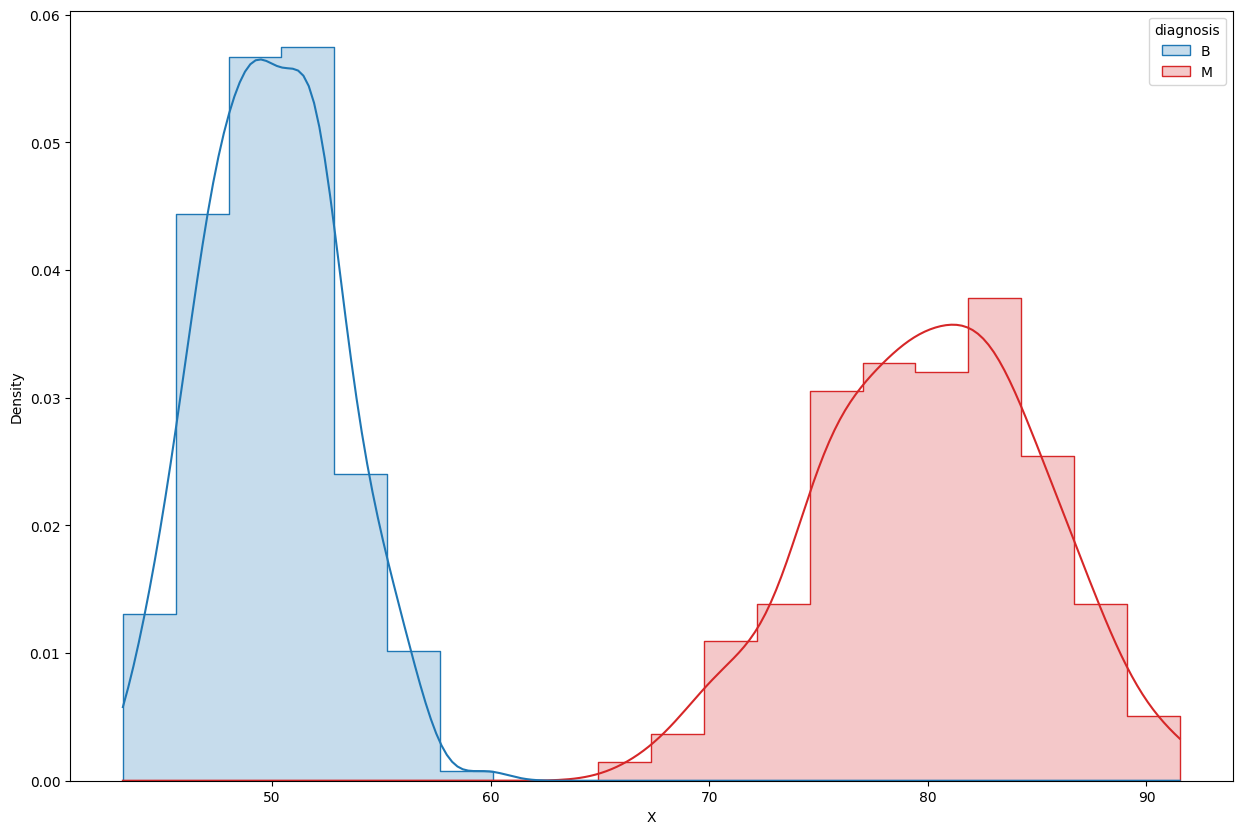

In [9]:
plt.figure(figsize=(15,10))
sns.histplot(data=sample_good_data,x=sample_good_data.columns[0],hue='diagnosis',stat='density',bins=20,kde=True,
             palette=[sns.color_palette()[0],sns.color_palette()[3]],element='step')


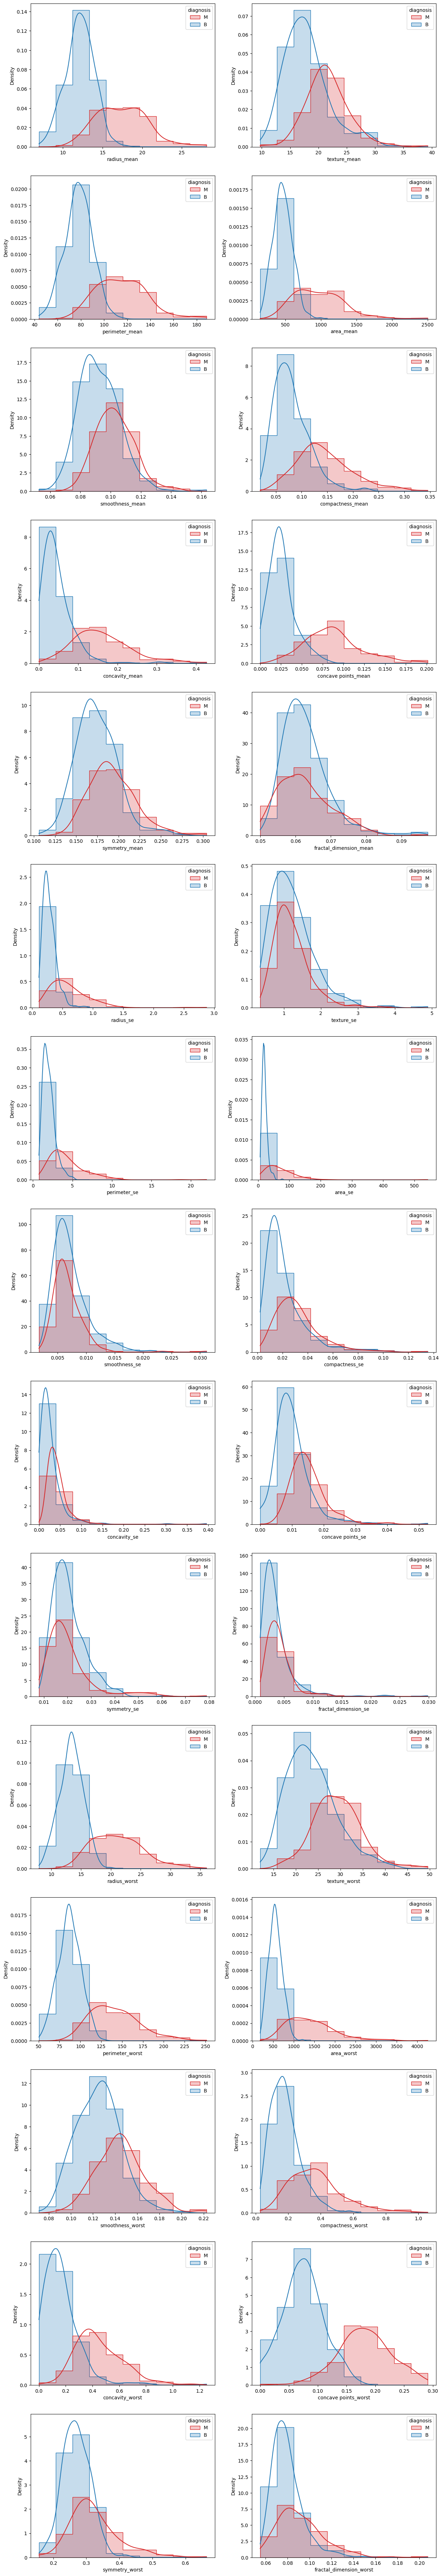

In [10]:
def plot_grid_histplot(data,data_columns,shape,figure_size):
    
    data_columns = np.array(data_columns).reshape(shape[0],shape[1])
    fig, axes = plt.subplots(shape[0],shape[1],figsize=figure_size)

    for i in range(data_columns.shape[0]):
        for j in range(data_columns.shape[1]):

            sns.histplot(data=data,x=data_columns[i,j],hue='diagnosis',stat='density',bins=10,kde=True,
                 palette=[sns.color_palette()[3],sns.color_palette()[0]],element='step',ax=axes[i,j])

plot_grid_histplot(data,data_columns,shape=(15,2),figure_size=(15,95))

In [11]:
data_copy = data.replace(to_replace=['B','M'],value=[0,1],inplace=False)
corr_df = abs(data_copy.corr())
corr_df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,1.000000,0.039769,0.074626,0.099770,0.073159,0.096893,0.012968,0.000096,0.050080,0.044158,...,0.082405,0.064720,0.079986,0.107187,0.010338,0.002968,0.023203,0.035174,0.044224,0.029866
diagnosis,0.039769,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,...,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.074626,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.099770,0.415185,0.323782,1.000000,0.329533,0.321086,0.023389,0.236702,0.302418,0.293464,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.073159,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.096893,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.012968,0.358560,0.170581,0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.000096,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.050080,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.044158,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661


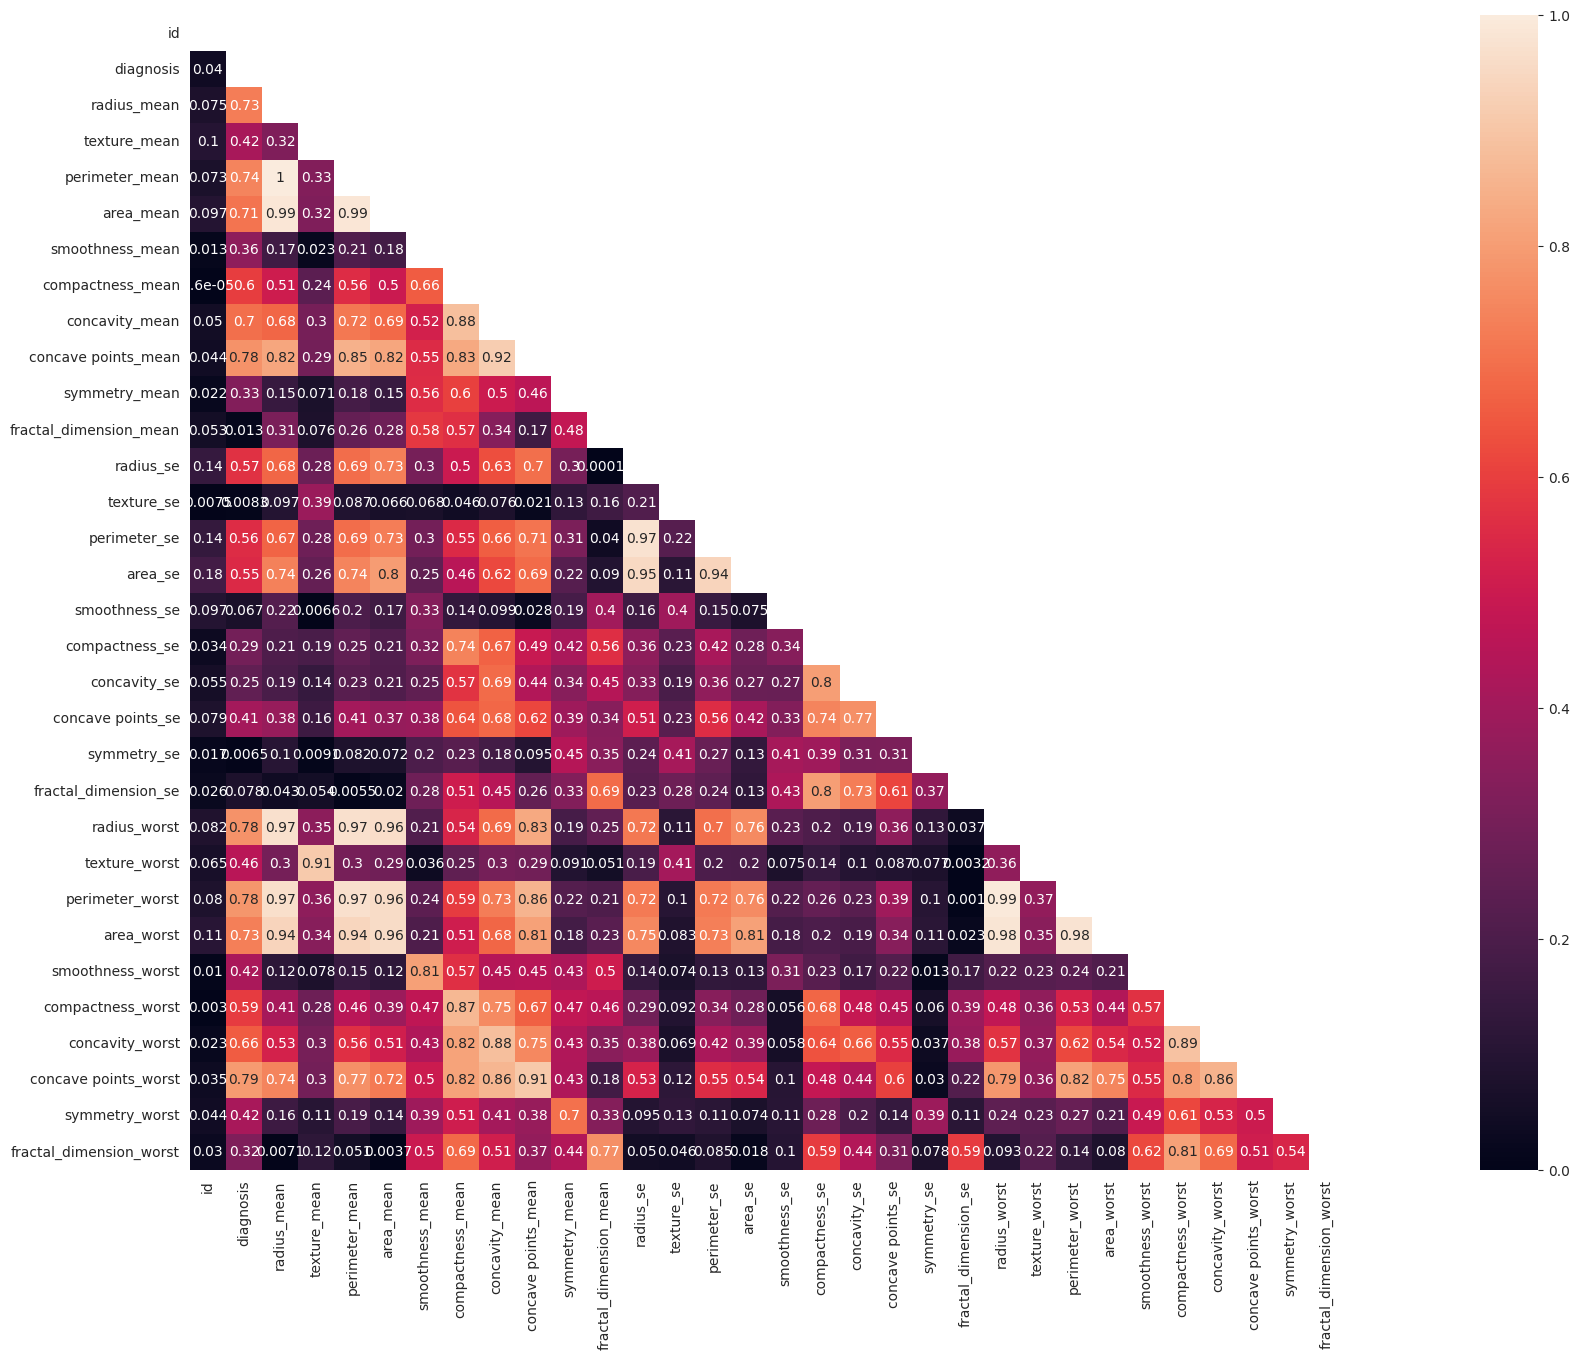

In [12]:
mask = np.zeros_like(corr_df)
mask[np.triu_indices_from(mask)] = True #True = generate a mask of lower triangle of matrix
with sns.axes_style("white"):
    f, ax = plt.subplots(figsize=(35,15))
    sns.heatmap(data=corr_df,vmin=0,vmax=1,mask=mask,square=True,annot=True)


In [13]:
strong_relation_features = pd.Series(corr_df['diagnosis']).nlargest(n=9).iloc[1:] #nlargest(n=9)==> take 8 features
strong_relation_features

concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
Name: diagnosis, dtype: float64

In [14]:
diagnosis = data_copy['diagnosis']
data_copy = data_copy[list(strong_relation_features.to_dict().keys())]
data_copy['diagnosis'] = diagnosis
data_copy

,concave points_worst,perimeter_worst,concave points_mean,radius_worst,perimeter_mean,area_worst,radius_mean,area_mean,diagnosis
0,0.2654,184.60,0.14710,25.380,122.80,2019.0,17.99,1001.0,1
1,0.1860,158.80,0.07017,24.990,132.90,1956.0,20.57,1326.0,1
2,0.2430,152.50,0.12790,23.570,130.00,1709.0,19.69,1203.0,1
3,0.2575,98.87,0.10520,14.910,77.58,567.7,11.42,386.1,1
4,0.1625,152.20,0.10430,22.540,135.10,1575.0,20.29,1297.0,1
...,...,...,...,...,...,...,...,...,...
564,0.2216,166.10,0.13890,25.450,142.00,2027.0,21.56,1479.0,1
565,0.1628,155.00,0.09791,23.690,131.20,1731.0,20.13,1261.0,1
566,0.1418,126.70,0.05302,18.980,108.30,1124.0,16.60,858.1,1
567,0.2650,184.60,0.15200,25.740,140.10,1821.0,20.60,1265.0,1


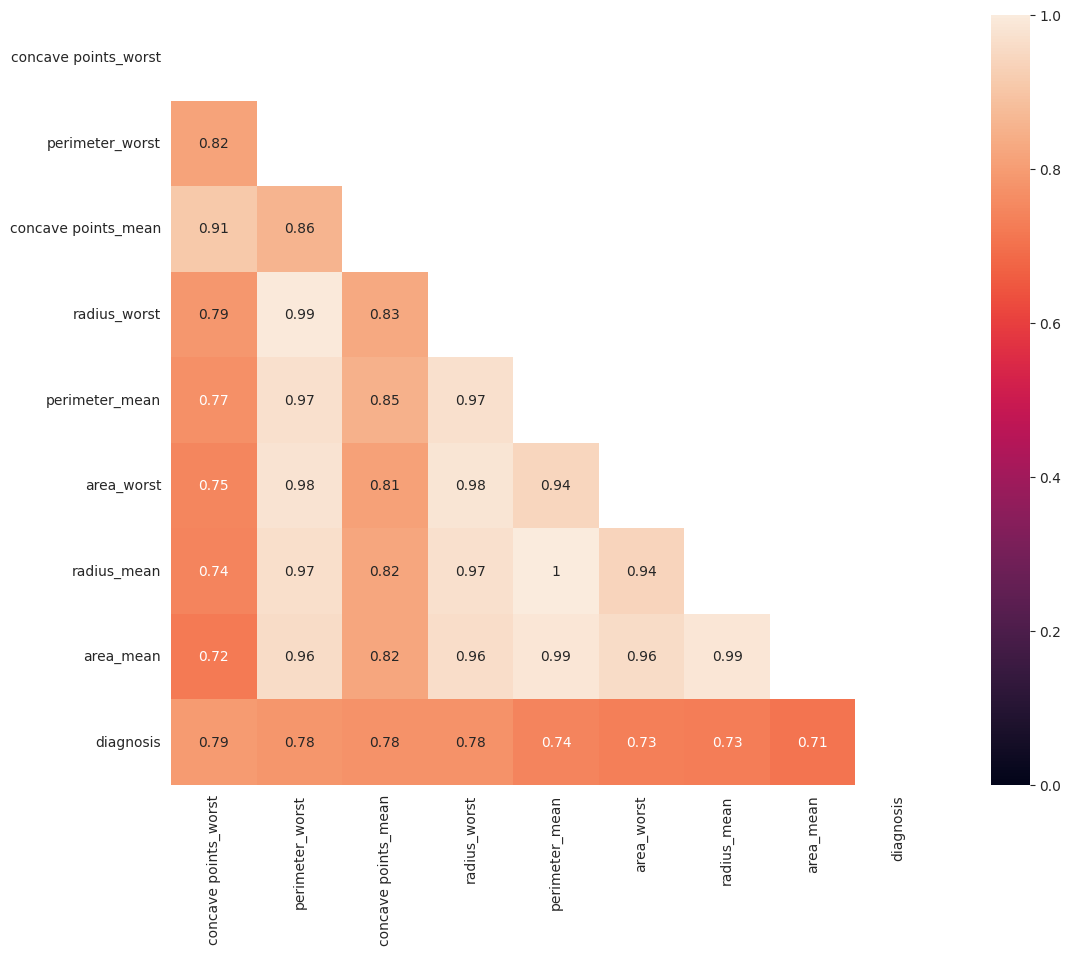

In [15]:

#Check heatmap again
mask = np.zeros_like(data_copy.corr())
mask[np.triu_indices_from(mask)] = True
with sns.axes_style("white"):
    f, ax = plt.subplots(figsize=(13,10))
    sns.heatmap(data=data_copy.corr(),vmin=0,vmax=1,mask=mask,square=True,annot=True)



In [16]:
data_copy

,concave points_worst,perimeter_worst,concave points_mean,radius_worst,perimeter_mean,area_worst,radius_mean,area_mean,diagnosis
0,0.2654,184.60,0.14710,25.380,122.80,2019.0,17.99,1001.0,1
1,0.1860,158.80,0.07017,24.990,132.90,1956.0,20.57,1326.0,1
2,0.2430,152.50,0.12790,23.570,130.00,1709.0,19.69,1203.0,1
3,0.2575,98.87,0.10520,14.910,77.58,567.7,11.42,386.1,1
4,0.1625,152.20,0.10430,22.540,135.10,1575.0,20.29,1297.0,1
...,...,...,...,...,...,...,...,...,...
564,0.2216,166.10,0.13890,25.450,142.00,2027.0,21.56,1479.0,1
565,0.1628,155.00,0.09791,23.690,131.20,1731.0,20.13,1261.0,1
566,0.1418,126.70,0.05302,18.980,108.30,1124.0,16.60,858.1,1
567,0.2650,184.60,0.15200,25.740,140.10,1821.0,20.60,1265.0,1


In [44]:
Feature = [col for col in data_copy.columns if col != 'diagnosis']
len(Feature)
Feature

['concave points_worst',
 'perimeter_worst',
 'concave points_mean',
 'radius_worst',
 'perimeter_mean',
 'area_worst',
 'radius_mean',
 'area_mean']

In [45]:
df = data.copy()

le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

X = df[Feature].values
Y = df['diagnosis'].values

X.shape, Feature
print(f"Class balance : B={sum(Y==0)}, M={sum(Y==1)}")
print(X.shape, Feature)


Class balance : B=357, M=212
(569, 8) ['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst', 'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean']


In [46]:
RANDOM_SEED = 42

def get_models():
    return {
        "GradientBoosting": GradientBoostingClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.1,
            subsample=0.8,
            random_state=RANDOM_SEED
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            random_state=RANDOM_SEED
        )
    }


In [47]:
N_FOLDS = 6
 
np.random.seed(RANDOM_SEED)
shuffled_idx = np.random.permutation(len(X))

folds = np.array_split(shuffled_idx, N_FOLDS)

print(f"Total data   : {len(X)}")
print(f"Fold sizes   : {[len(f) for f in folds]}")
print(f"Approx ratio : train={4/6*100:.1f}%  val={1/6*100:.1f}%  test={1/6*100:.1f}%\n")

Total data   : 569
Fold sizes   : [95, 95, 95, 95, 95, 94]
Approx ratio : train=66.7%  val=16.7%  test=16.7%



In [58]:
results = []

print(f"{'Combo':>6} | {'Val':>4} {'Test':>5} | "
      f"{'GB_val':>8} {'GB_test':>9} | "
      f"{'RF_val':>7} {'RF_test':>8}")

for combo_num, (val_f, test_f) in enumerate(permutations(range(N_FOLDS), 2), start=1):
 
    train_folds = [i for i in range(N_FOLDS) if i != val_f and i != test_f]
 
    train_idx = np.concatenate([folds[i] for i in train_folds])
    val_idx   = folds[val_f]
    test_idx  = folds[test_f]
 
    X_train, y_train = X[train_idx], Y[train_idx]
    X_val,   y_val   = X[val_idx],   Y[val_idx]
    X_test,  y_test  = X[test_idx],  Y[test_idx]
 
    row = {
        "combo"       : combo_num,
        "train_folds" : str(train_folds),
        "val_fold"    : val_f,
        "test_fold"   : test_f,
    }
 
    models = get_models()
    for model_name, model in models.items():
        model.fit(X_train, y_train)
 
        val_pred  = model.predict(X_val)
        test_pred = model.predict(X_test)
 
        val_acc  = accuracy_score(y_val,  val_pred)
        test_acc = accuracy_score(y_test, test_pred)
        val_f1   = f1_score(y_val,  val_pred)
        test_f1  = f1_score(y_test, test_pred)
 
        row[f"{model_name}_val_acc"]  = round(val_acc,  4)
        row[f"{model_name}_test_acc"] = round(test_acc, 4)
        row[f"{model_name}_val_f1"]   = round(val_f1,   4)
        row[f"{model_name}_test_f1"]  = round(test_f1,  4)
 
    results.append(row)
 
    print(f"  #{combo_num:>2}    | {val_f:>3}  {test_f:>4}  | "
          f"{row['GradientBoosting_val_acc']:>8.4f} {row['GradientBoosting_test_acc']:>9.4f} | "
          f"{row['RandomForest_val_acc']:>7.4f} {row['RandomForest_test_acc']:>8.4f}")
 

 Combo |  Val  Test |   GB_val   GB_test |  RF_val  RF_test
  # 1    |   0     1  |   0.9684    0.9684 |  0.9579   0.9579
  # 2    |   0     2  |   0.9684    0.9474 |  0.9579   0.9579
  # 3    |   0     3  |   0.9579    0.9579 |  0.9579   0.9579
  # 4    |   0     4  |   0.9579    0.9368 |  0.9579   0.9263
  # 5    |   0     5  |   0.9474    0.9255 |  0.9474   0.9362
  # 6    |   1     0  |   0.9684    0.9684 |  0.9579   0.9579
  # 7    |   1     2  |   0.9474    0.9263 |  0.9684   0.9474
  # 8    |   1     3  |   0.9474    0.8947 |  0.9474   0.8947
  # 9    |   1     4  |   0.9158    0.9474 |  0.9368   0.9368
  #10    |   1     5  |   0.9684    0.9574 |  0.9684   0.9468
  #11    |   2     0  |   0.9474    0.9684 |  0.9579   0.9579
  #12    |   2     1  |   0.9263    0.9474 |  0.9474   0.9684
  #13    |   2     3  |   0.9474    0.9368 |  0.9684   0.9368
  #14    |   2     4  |   0.9579    0.9158 |  0.9579   0.9368
  #15    |   2     5  |   0.9579    0.9468 |  0.9579   0.9468
  #16    |

In [59]:
results_df = pd.DataFrame(results)

for model_name in ["GradientBoosting", "RandomForest"]:
    col = f"{model_name}_test_acc"
    print(f"\n{model_name}:")
    print(f"  Mean  = {results_df[col].mean():.4f}")
    print(f"  Std   = {results_df[col].std():.4f}")
    print(f"  Min   = {results_df[col].min():.4f}")
    print(f"  Max   = {results_df[col].max():.4f}")


GradientBoosting:
  Mean  = 0.9434
  Std   = 0.0185
  Min   = 0.8947
  Max   = 0.9684

RandomForest:
  Mean  = 0.9458
  Std   = 0.0164
  Min   = 0.8947
  Max   = 0.9684


In [ ]:
for model_name in ["GradientBoosting", "RandomForest"]:
    val_col  = f"{model_name}_val_acc"
    test_col = f"{model_name}_test_acc"
 
    best_row = results_df.loc[results_df[val_col].idxmax()]
 
    print(f"\n▶ {model_name}")
    print(f"  Combo #{int(best_row['combo'])}"
          f"  │  Train folds: {best_row['train_folds']}"
          f"  │  Val fold: {int(best_row['val_fold'])}"
          f"  │  Test fold: {int(best_row['test_fold'])}")
    print(f"  Val  Accuracy = {best_row[val_col]:.4f}"
          f"   │  Val  F1 = {best_row[f'{model_name}_val_f1']:.4f}")
    print(f"  Test Accuracy = {best_row[test_col]:.4f}"
          f"   │  Test F1 = {best_row[f'{model_name}_test_f1']:.4f}")
 
    train_folds_best = [i for i in range(N_FOLDS)
                        if i != int(best_row['val_fold'])
                        and i != int(best_row['test_fold'])]
    train_idx = np.concatenate([folds[i] for i in train_folds_best])
    val_idx   = folds[int(best_row['val_fold'])]
    test_idx  = folds[int(best_row['test_fold'])]
 
    X_train, y_train = X[train_idx], Y[train_idx]
    X_val,   y_val   = X[val_idx],   Y[val_idx]
    X_test,  y_test  = X[test_idx],  Y[test_idx]
 
    models_best = get_models()
    best_model  = models_best[model_name]
    best_model.fit(X_train, y_train)
 
    print("\n  Classification Report (Test Set):")
    print(classification_report(
        y_test, best_model.predict(X_test),
        target_names=["Benign", "Malignant"]
    ))


▶ GradientBoosting
  Combo #1  │  Train folds: [2, 3, 4, 5]  │  Val fold: 0  │  Test fold: 1
  Val  Accuracy = 0.9684   │  Val  F1 = 0.9552
  Test Accuracy = 0.9684   │  Test F1 = 0.9552

  Classification Report (Test Set):
              precision    recall  f1-score   support

      Benign       0.97      0.98      0.98        61
   Malignant       0.97      0.94      0.96        34

    accuracy                           0.97        95
   macro avg       0.97      0.96      0.97        95
weighted avg       0.97      0.97      0.97        95


▶ RandomForest
  Combo #7  │  Train folds: [0, 3, 4, 5]  │  Val fold: 1  │  Test fold: 2
  Val  Accuracy = 0.9684   │  Val  F1 = 0.9565
  Test Accuracy = 0.9474   │  Test F1 = 0.9153

  Classification Report (Test Set):
              precision    recall  f1-score   support

      Benign       0.95      0.97      0.96        65
   Malignant       0.93      0.90      0.92        30

    accuracy                           0.95        95
   macro 

/tmp/ipykernel_15279/1998927899.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis')


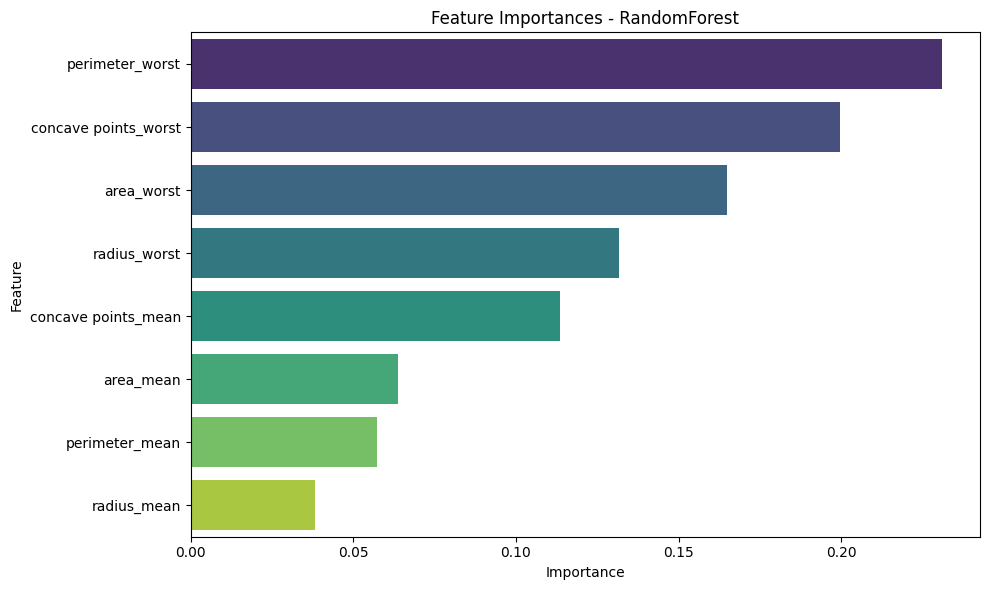

In [ ]:
fi_df = pd.DataFrame({
    'feature'    : Feature,
    'importance' : importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis')
plt.title(f'Feature Importances - {model_name}')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

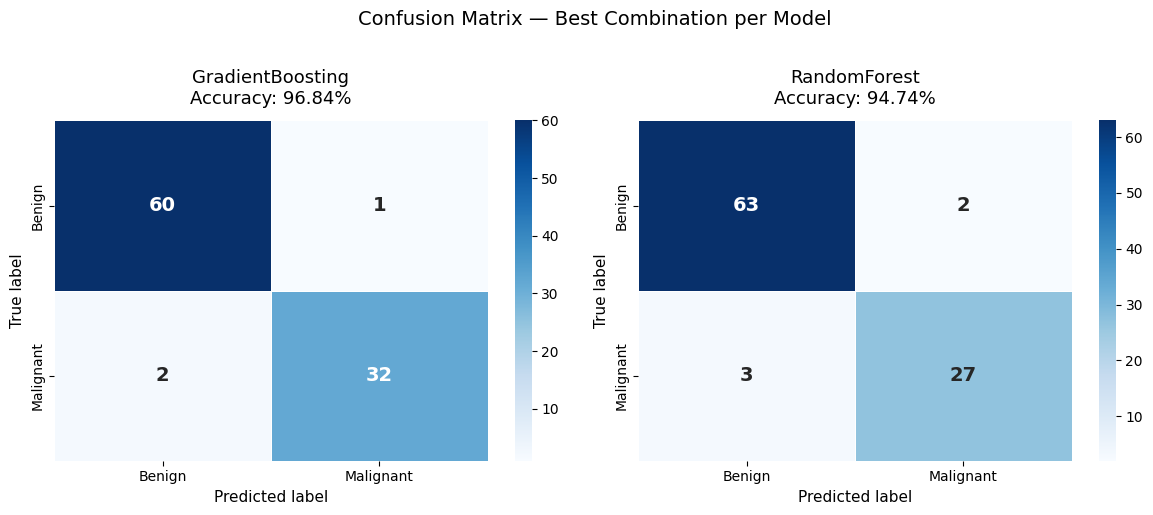

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, model_name in enumerate(["GradientBoosting", "RandomForest"]):
    
    # ambil best combo per model
    val_col = f"{model_name}_val_acc"
    best_row = results_df.loc[results_df[val_col].idxmax()]
    
    train_folds_best = [i for i in range(N_FOLDS)
                        if i != int(best_row['val_fold'])
                        and i != int(best_row['test_fold'])]
    
    X_train = X[np.concatenate([folds[i] for i in train_folds_best])]
    y_train = Y[np.concatenate([folds[i] for i in train_folds_best])]
    X_test  = X[folds[int(best_row['test_fold'])]]
    y_test  = Y[folds[int(best_row['test_fold'])]]
    
    model = get_models()[model_name]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    test_acc = accuracy_score(y_test, y_pred)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Benign', 'Malignant'],
        yticklabels=['Benign', 'Malignant'],
        linewidths=0.5,
        ax=axes[idx],
        annot_kws={"size": 14, "weight": "bold"}
    )
    
    axes[idx].set_title(f'{model_name}\nAccuracy: {test_acc:.2%}', fontsize=13, pad=12)
    axes[idx].set_xlabel('Predicted label', fontsize=11)
    axes[idx].set_ylabel('True label', fontsize=11)

plt.suptitle('Confusion Matrix — Best Combination per Model', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [55]:
for model_name in ["GradientBoosting", "RandomForest"]:
    val_col = f"{model_name}_val_acc"
    best_row = results_df.loc[results_df[val_col].idxmax()]
    
    print(f"\n{model_name}:")
    print(f"  Best Combo: #{int(best_row['combo'])}")
    print(f"  Training Folds: {best_row['train_folds']}")
    print(f"  Validation Fold: {int(best_row['val_fold'])}")
    print(f"  Test Fold: {int(best_row['test_fold'])}")
    print(f"  Val Accuracy: {best_row[val_col]:.4f}")
    print(f"  Test Accuracy: {best_row[f'{model_name}_test_acc']:.4f}")


GradientBoosting:
  Best Combo: #1
  Training Folds: [2, 3, 4, 5]
  Validation Fold: 0
  Test Fold: 1
  Val Accuracy: 0.9684
  Test Accuracy: 0.9684

RandomForest:
  Best Combo: #7
  Training Folds: [0, 3, 4, 5]
  Validation Fold: 1
  Test Fold: 2
  Val Accuracy: 0.9684
  Test Accuracy: 0.9474


In [56]:
for model_name in ["GradientBoosting", "RandomForest"]:
    val_col = f"{model_name}_val_acc"
    top_5 = results_df.nlargest(5, val_col)[['combo', 'train_folds', 'val_fold', 'test_fold', val_col, f'{model_name}_test_acc']]
    print(f"\n{model_name} - Top 5 Best Combos:")
    print(top_5)


GradientBoosting - Top 5 Best Combos:
   combo   train_folds  val_fold  test_fold  GradientBoosting_val_acc  \
0      1  [2, 3, 4, 5]         0          1                    0.9684   
1      2  [1, 3, 4, 5]         0          2                    0.9684   
5      6  [2, 3, 4, 5]         1          0                    0.9684   
9     10  [0, 2, 3, 4]         1          5                    0.9684   
2      3  [1, 2, 4, 5]         0          3                    0.9579   

   GradientBoosting_test_acc  
0                     0.9684  
1                     0.9474  
5                     0.9684  
9                     0.9574  
2                     0.9579  

RandomForest - Top 5 Best Combos:
    combo   train_folds  val_fold  test_fold  RandomForest_val_acc  \
6       7  [0, 3, 4, 5]         1          2                0.9684   
9      10  [0, 2, 3, 4]         1          5                0.9684   
12     13  [0, 1, 4, 5]         2          3                0.9684   
0       1  [2, 3, 4, 